# The Imaging KG as a Knowledge Base

The KG isn't just a store of numbers — it's queried, reasoned over, and used to interpret **new**
patients. This notebook demonstrates each of those roles on the **real FLARE23 KG** we built
(`kg/graph/imaging_kg_flare23.ttl`, 85k triples; `kg/data/corpus_flare_train.json`). Everything here
runs in seconds, no GPU.

**Roles shown:** ① structured retrieval (SPARQL) · ② semantic grounding (SNOMED/NCIt) ·
③ cohort reasoning · ④ observability-aware similarity (OAKG) · ⑤ validating a new patient.

In [1]:
import os, json, numpy as np, pandas as pd
from rdflib import Graph
import matplotlib.pyplot as plt
os.chdir("/home/ud3d4/Desktop/SWOG")   # run from repo root regardless of where the notebook lives

g = Graph(); g.parse("kg/graph/imaging_kg_flare23.ttl", format="turtle")
corpus = json.load(open("kg/data/corpus_flare_train.json"))["records"]
MMKG = "http://example.org/mmkg/schema/"
print(f"KG: {len(g):,} triples | {len(corpus):,} patients")

KG: 85,063 triples | 1,312 patients


## ① Structured retrieval — ask the KG a question (SPARQL)

The KG answers clinical-style queries directly. E.g. *"which patients have the largest kidney
tumors?"* and *"how many tumors are recorded per organ?"* — resolved by graph pattern matching.

In [2]:
kidney_q = """
PREFIX mmkg: <http://example.org/mmkg/schema/>
SELECT ?case ?vol ?dia ?burden WHERE {
  ?org a mmkg:Kidney ; mmkg:has_lesion ?les .
  ?case mmkg:depicts_organ ?org .
  ?les mmkg:gt_volume_cm3 ?vol ; mmkg:gt_max_diameter_mm ?dia ; mmkg:tumorBurden ?burden .
} ORDER BY DESC(?vol) LIMIT 5 """
print("Largest kidney tumors:")
for r in g.query(kidney_q):
    print(f"  {str(r.case).split('/')[-1]:20s} {float(r.vol):7.1f} cc  {float(r.dia):5.1f} mm  burden={r.burden}")

count_q = """
PREFIX mmkg: <http://example.org/mmkg/schema/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?organType (COUNT(?les) AS ?n) WHERE {
  ?les a mmkg:Lesion ; mmkg:located_in ?org . ?org a ?organType .
  FILTER(?organType != mmkg:Organ)
} GROUP BY ?organType ORDER BY DESC(?n) """
print("\nTumors recorded per organ type:")
for r in g.query(count_q):
    print(f"  {str(r.organType).split('/')[-1]:16s} {int(r.n)}")

Largest kidney tumors:
  case_FLARE23_2068     1484.7 cc  166.2 mm  burden=high
  case_FLARE23_0955     1401.0 cc  192.9 mm  burden=high
  case_FLARE23_1158     1387.3 cc  154.8 mm  burden=high
  case_FLARE23_0286     1076.5 cc  141.9 mm  burden=high
  case_FLARE23_0212      807.1 cc  133.1 mm  burden=high

Tumors recorded per organ type:
  Pancreas         281
  Kidney           202
  Liver            125


## ② Semantic grounding — the KG speaks standard terminologies

Every organ/lesion is linked to standard codes (SNOMED CT / NCIt), so the KG is **interoperable** and
reasoners can use external hierarchies (e.g. *kidney tumor is-a genitourinary neoplasm*).

In [3]:
ground_q = """
PREFIX mmkg: <http://example.org/mmkg/schema/>
SELECT DISTINCT ?organ ?system ?code ?display WHERE {
  ?org a mmkg:Organ ; mmkg:mapped_to_concept ?con .
  ?org a ?organ . FILTER(?organ != mmkg:Organ)
  ?con mmkg:system ?system ; mmkg:code ?code ; mmkg:display ?display .
} LIMIT 12 """
print("organ  ->  terminology grounding")
for r in g.query(ground_q):
    print(f"  {str(r.organ).split('/')[-1]:14s} {r.system:9s} {r.code:12s} {r.display}")

organ  ->  terminology grounding
  Aorta          SNOMED CT 15825003     Aorta
  Duodenum       SNOMED CT 38848004     Duodenum
  Esophagus      SNOMED CT 32849002     Esophagus
  Gallbladder    SNOMED CT 28231008     Gallbladder
  InferiorVenaCava SNOMED CT 64131007     InferiorVenaCava
  AdrenalGland   SNOMED CT 23451007     AdrenalGland
  Kidney         SNOMED CT 18639004     Kidney
  Liver          SNOMED CT 10200004     Liver
  Pancreas       SNOMED CT 15776009     Pancreas
  Kidney         SNOMED CT 9846003      Kidney
  Spleen         SNOMED CT 78961009     Spleen
  Stomach        SNOMED CT 69695003     Stomach


## ③ Cohort reasoning — the population the KG encodes

Aggregate the KG into **reference distributions**. These are what let the KG *judge* a new patient
(next sections): a value is plausible if it sits inside the cohort it's seen.

,organ,n,median_cc,p2.5,p97.5
0,liver,1311,1566.5,942.2,2753.8
1,spleen,1306,223.7,82.6,622.3
2,pancreas,1311,81.8,33.5,150.2
3,right_kidney,1301,183.6,105.7,334.0
4,left_kidney,1299,189.1,107.3,364.4


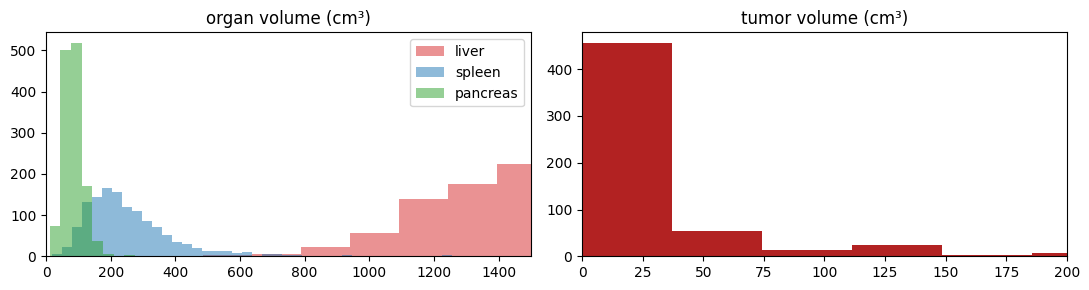

In [4]:
def organ_vols(name):
    return [od["organ_volume_cm3"] for r in corpus for o, od in r["organs"].items() if o == name]

rows = []
for o in ["liver", "spleen", "pancreas", "right_kidney", "left_kidney"]:
    v = np.array(organ_vols(o))
    rows.append({"organ": o, "n": len(v), "median_cc": round(np.median(v),1),
                 "p2.5": round(np.percentile(v,2.5),1), "p97.5": round(np.percentile(v,97.5),1)})
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(11,3))
for o,c in [("liver","tab:red"),("spleen","tab:blue"),("pancreas","tab:green")]:
    ax[0].hist(organ_vols(o), bins=40, alpha=0.5, label=o, color=c)
ax[0].set_title("organ volume (cm³)"); ax[0].legend(); ax[0].set_xlim(0,1500)
tv=[od["tumor_volume_cm3"] for r in corpus for od in r["organs"].values() if od.get("has_tumor")]
ax[1].hist(tv, bins=40, color="firebrick"); ax[1].set_title("tumor volume (cm³)"); ax[1].set_xlim(0,200)
plt.tight_layout(); plt.show()

## ④ Observability-aware similarity (OAKG) — find comparable patients

The core idea: patients are described by **only the organs actually observed** — an unobserved organ
is *unknown*, never 0. Similarity is computed over **jointly-observed** phenotypes and down-weighted
by **γ** (how much evidence two patients share). So a patient who overlaps on 1 organ is not called a
perfect match just because that one value is close.

In [5]:
def observed(rec):
    return {o: od["organ_volume_cm3"] for o, od in rec["organs"].items()}

def oakg_similarity(a, b):
    A, B = observed(a), observed(b)
    shared = set(A) & set(B)
    if not shared:
        return 0.0
    gamma = len(shared) / len(set(A) | set(B))                 # shared-evidence weight (Jaccard)
    close = np.mean([1 - abs(A[o]-B[o])/(A[o]+B[o]+1e-9) for o in shared])
    return round(gamma * close, 3)

q = next(r for r in corpus if any(od.get("has_tumor") for od in r["organs"].values()))
ranked = sorted((r for r in corpus if r is not q),
                key=lambda r: oakg_similarity(q, r), reverse=True)[:5]
print(f"Query patient: {q['case_id']}  (observed: {sorted(observed(q))})")
print("Most similar (observability-aware):")
for r in ranked:
    print(f"  {r['case_id']:16s} sim={oakg_similarity(q,r):.3f}  shared={sorted(set(observed(q))&set(observed(r)))}")

Query patient: FLARE23_0003  (observed: ['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen'])
Most similar (observability-aware):
  FLARE23_0286     sim=0.912  shared=['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen']
  FLARE23_0416     sim=0.892  shared=['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen']
  FLARE23_0457     sim=0.888  shared=['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen']
  FLARE23_0262     sim=0.887  shared=['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen']
  FLARE23_0749     sim=0.884  shared=['left_kidney', 'liver', 'pancreas', 'right_kidney', 'spleen']


## ⑤ Using the KG on a NEW patient — validate + contextualise

A new CT is segmented **autonomously** (no ground truth). The KG then does two jobs no single scan
can: (a) **validate** each phenotype against the cohort distribution — GT-free plausibility, and
(b) **retrieve** the most similar known patients. This is the inference role, and it **self-improves**
as new patients are admitted (the distributions get richer).

In [6]:
def plausibility(name, value):
    v = np.array(organ_vols(name))
    pct = round(float((v < value).mean()*100), 1)
    z = round(float((value - v.mean())/(v.std()+1e-9)), 2)
    flag = "OK" if 2.5 <= pct <= 97.5 else "⚠️ OUTLIER"
    return {"organ": name, "new_value_cc": value, "cohort_median": round(float(np.median(v)),1),
            "percentile": pct, "z": z, "verdict": flag}

# two synthetic "new patients" from autonomous segmentation: one plausible, one with a seg error
new_ok  = {"liver": 1450, "spleen": 210, "pancreas": 70, "right_kidney": 150, "left_kidney": 160}
new_bad = {"liver": 4900, "spleen": 205, "pancreas": 63, "right_kidney": 148}   # liver over-segmented

for tag, patient in [("plausible patient", new_ok), ("patient with a segmentation error", new_bad)]:
    print(f"=== {tag} ===")
    display(pd.DataFrame([plausibility(o, v) for o, v in patient.items()]))

# retrieve similar known patients for the plausible one
fake = {"case_id": "NEW_CT_001", "organs": {o: {"organ_volume_cm3": v} for o, v in new_ok.items()}}
sim_hits = sorted(corpus, key=lambda r: oakg_similarity(fake, r), reverse=True)[:3]
print("Most similar known patients to NEW_CT_001:", [r["case_id"] for r in sim_hits])

=== plausible patient ===


,organ,new_value_cc,cohort_median,percentile,z,verdict
0,liver,1450,1566.5,37.2,-0.41,OK
1,spleen,210,223.7,45.4,-0.32,OK
2,pancreas,70,81.8,33.3,-0.34,OK
3,right_kidney,150,183.6,22.1,-0.55,OK
4,left_kidney,160,189.1,26.3,-0.47,OK


=== patient with a segmentation error ===


,organ,new_value_cc,cohort_median,percentile,z,verdict
0,liver,4900,1566.5,99.9,6.79,⚠️ OUTLIER
1,spleen,205,223.7,43.0,-0.36,OK
2,pancreas,63,81.8,23.9,-0.50,OK
3,right_kidney,148,183.6,20.8,-0.58,OK


Most similar known patients to NEW_CT_001: ['FLARE23_0808', 'FLARE23_0373', 'FLARE23_1628']


## Summary — the KG's jobs as a knowledge base

| Role | How | Shown in |
|---|---|---|
| **Retrieval** | SPARQL over the graph | ① |
| **Semantic interoperability** | SNOMED/NCIt grounding | ② |
| **Cohort reasoning** | reference distributions | ③ |
| **Observability-aware similarity** | jointly-observed + γ (unobserved ≠ 0) | ④ |
| **Validate a new patient** | GT-free plausibility vs cohort | ⑤ |
| **Contextualise a new patient** | retrieve similar known cases | ⑤ |
| **Evolve** | each admitted patient sharpens the distributions | ⑤ |

The same graph that stores the phenotypes is what *interprets* a new, unlabeled scan — GT-free — and
gets better as it grows. The interactive version of all this is `app/oakg_query_app.py`.